In [1]:
%pip install torch torchvision opencv-contrib-python numpy pandas matplotlib seaborn scikit-learn tqdm grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# transformation for the Training (with Data Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Trasformation for Validation and Test (only resize and normalization, without distortion)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
dataset_path = 'dataset/Garbage classification'

# two view of the dataset, one for training and one for testing
full_train_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)
full_test_dataset = datasets.ImageFolder(root=dataset_path, transform=test_transforms)

# let's verify that PyTorch is seeing all 6 classes
print(f"Classes found: {full_train_dataset.classes}")

# different dataset groups size
total_size = len(full_train_dataset)
train_size = int(0.7 * total_size)   # 70%
val_size = int(0.15 * total_size)    # 15%
test_size = total_size - train_size - val_size # 15%

print(f"Tot Images: {total_size}")
print(f"Training: {train_size} | Validation: {val_size} | Test: {test_size}")

# we need to create random index to mix photos before dividing them, so we use seed to make the action reproducible
torch.manual_seed(42)
indices = torch.randperm(total_size).tolist()

train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

# we assign the photos to the various groups. we pass "full_test_dataset" to val and test to not have the data augmentation
train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_test_dataset, val_idx)
test_data = Subset(full_test_dataset, test_idx)

# create the DataLoader that loads the packets to the GPU
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Data ready")

Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Tot Images: 2527
Training: 1768 | Validation: 379 | Test: 380
Data ready


In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models

# 1. check if GPU is active
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch type: {device}")

# Define the local filename for the original ResNet18 weights
base_weights_path = 'old_resnet18_base.pth'

# --- THE SMART OFFLINE CHECK ---
if os.path.exists(base_weights_path):
    print("Local ResNet18 base weights found! Loading completely offline...")
    # Initialize the empty architecture (weights=None stops the internet download)
    model = models.resnet18(weights=None)
    # Load our local weights into the empty shell
    model.load_state_dict(torch.load(base_weights_path))
else:
    print("Base weights not found locally. Downloading from the internet...")
    # Download the default weights
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Save a copy in our project folder so we never have to download it again!
    torch.save(model.state_dict(), base_weights_path)
    print("Base weights successfully saved locally for future use!")
# -------------------------------

# 2. stop the parameters so we don't train from zero
for param in model.parameters():
    param.requires_grad = False

# 3. modify only the last layer (Fully Connected Layer)
num_ftrs = model.fc.in_features
class_number = 6 # we only have 6 classes (cardboard, glass, metal, paper, plastic, generic)

# create new final layer that is not freezed like the other ones, so it's the only one that will learn
model.fc = nn.Linear(num_ftrs, class_number)

# 4. move the model on the GPU/CPU
model = model.to(device)

print("ResNet18 model loaded and modified successfully")

Torch type: cpu
Base weights not found locally. Downloading from the internet...
Base weights successfully saved locally for future use!
ResNet18 model loaded and modified successfully


In [ ]:
import torch.optim as optim

# for the Loss Function (Error) we use CrossEntropyLoss (standard for the multi-class classification)
criterion = nn.CrossEntropyLoss()

# for the Optimizer (that corrects the errors) we use Adam
# we only optimize the final layer parameters (model.fc) because the rest is freezed
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss and and Optimizer ready")

Loss e and Optimizer ready


In [ ]:
import os
import torch

# Define the exact name of the file where we want to save/load our AI brain
weights_path = 'old_garbage_resnet18_weights.pth'

# --- THE SMART CHECK ---
# os.path.exists() checks if the file is already on your hard drive
if os.path.exists(weights_path):
    print(f"File '{weights_path}' found! Loading the pre-trained AI...")
    
    # Load the weights directly into our model
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    
    print("Model loaded successfully! You can skip the training loop and go straight to testing.")
    
    # Optional: We can set a flag to remember we already have the model
    skip_training = True

else:
    print(f"File '{weights_path}' NOT found. Starting the training from scratch...")
    
    # We set a flag to tell the next cell to run the training loop
    skip_training = False

File 'garbage_resnet18_weights.pth' found! Loading the pre-trained AI...
Model loaded successfully! You can skip the training loop and go straight to testing.


In [ ]:
import copy
import time
import torch

# We only run the training if we didn't load the weights in the previous cell
if not skip_training:
    epochs = 15
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - start_time
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    # load the best weights back into the model
    model.load_state_dict(best_model_wts)
    
    # --- AUTOMATIC SAVING ---
    # Save the newly trained model to disk so we don't have to train it again tomorrow!
    torch.save(model.state_dict(), weights_path)
    print(f"Model successfully saved to '{weights_path}'!")
    
else:
    print("Training loop skipped because the model is already trained and loaded.")

Epoch 1/30
----------
Train Loss: 0.5003 Acc: 0.8247
Val Loss: 0.5795 Acc: 0.7863

Epoch 2/30
----------
Train Loss: 0.4944 Acc: 0.8303
Val Loss: 0.5837 Acc: 0.7757

Epoch 3/30
----------
Train Loss: 0.5100 Acc: 0.8179
Val Loss: 0.6147 Acc: 0.7625

Epoch 4/30
----------
Train Loss: 0.4755 Acc: 0.8298
Val Loss: 0.5874 Acc: 0.7863

Epoch 5/30
----------
Train Loss: 0.4742 Acc: 0.8269
Val Loss: 0.5764 Acc: 0.7836

Epoch 6/30
----------
Train Loss: 0.4267 Acc: 0.8535
Val Loss: 0.5634 Acc: 0.8021

Epoch 7/30
----------
Train Loss: 0.4271 Acc: 0.8529
Val Loss: 0.5588 Acc: 0.7863

Epoch 8/30
----------
Train Loss: 0.4412 Acc: 0.8541
Val Loss: 0.5534 Acc: 0.7836

Epoch 9/30
----------
Train Loss: 0.4371 Acc: 0.8433
Val Loss: 0.5623 Acc: 0.7889

Epoch 10/30
----------
Train Loss: 0.4319 Acc: 0.8512
Val Loss: 0.5437 Acc: 0.7836

Epoch 11/30
----------
Train Loss: 0.4310 Acc: 0.8546
Val Loss: 0.5543 Acc: 0.7968

Epoch 12/30
----------
Train Loss: 0.4201 Acc: 0.8586
Val Loss: 0.5369 Acc: 0.8021

E

Starting evaluation on the Test Set...

Classes detected: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

--- Classification Report ---
              precision    recall  f1-score   support

   cardboard       0.95      0.90      0.92        59
       glass       0.70      0.77      0.73        78
       metal       0.68      0.87      0.76        61
       paper       0.84      0.83      0.84        92
     plastic       0.86      0.65      0.74        66
       trash       0.65      0.54      0.59        24

    accuracy                           0.78       380
   macro avg       0.78      0.76      0.76       380
weighted avg       0.79      0.78      0.78       380



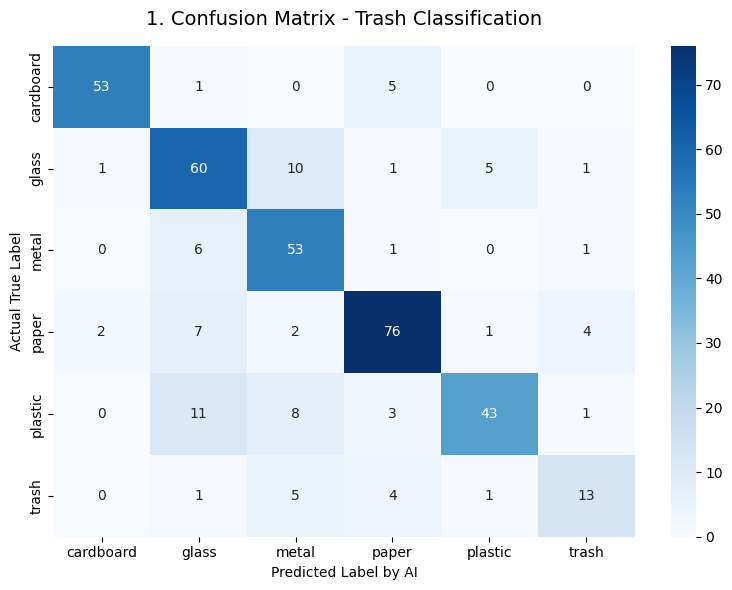

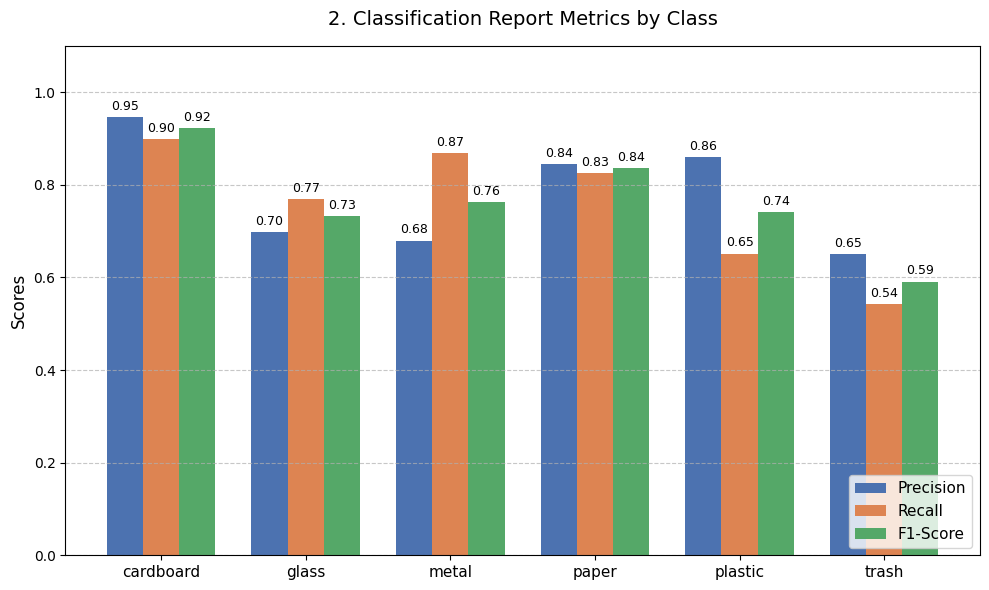

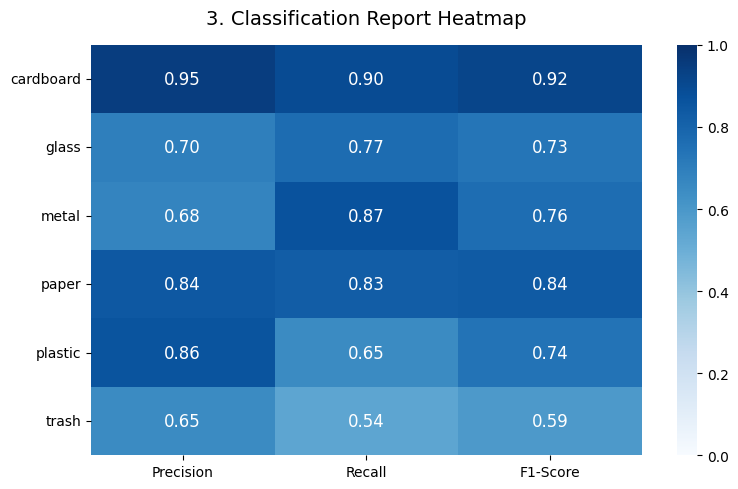

All evaluations completed and plots saved to disk!


In [8]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Set the model to evaluation mode
model.eval()

all_preds = []
all_labels = []

print("Starting evaluation on the Test Set...")

# 2. Iterate over the test data
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # append the current batch of predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Retrieve the actual class names
class_names = full_test_dataset.classes
print(f"\nClasses detected: {class_names}\n")

# --- TEXT REPORT ---
print("--- Classification Report ---")
# Print the standard text report
print(classification_report(all_labels, all_preds, target_names=class_names))

# Get the report as a dictionary to extract dynamic values for our plots
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

# Extract precision, recall, and f1-score lists dynamically
precision = [report_dict[cls]['precision'] for cls in class_names]
recall = [report_dict[cls]['recall'] for cls in class_names]
f1_score = [report_dict[cls]['f1-score'] for cls in class_names]

# ==========================================
# PLOT 1: CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('1. Confusion Matrix - Trash Classification', fontsize=14, pad=15)
plt.ylabel('Actual True Label')
plt.xlabel('Predicted Label by AI')
plt.tight_layout()
plt.savefig('1_confusion_matrix.png', dpi=300)
plt.show()

# ==========================================
# PLOT 2: GROUPED BAR CHART (METRICS)
# ==========================================
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x, recall, width, label='Recall', color='#DD8452')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#55A868')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('2. Classification Report Metrics by Class', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.savefig('2_metrics_barchart.png', dpi=300)
plt.show()

# ==========================================
# PLOT 3: METRICS HEATMAP
# ==========================================
data_metrics = np.array([precision, recall, f1_score]).T
df_metrics = pd.DataFrame(data_metrics, columns=['Precision', 'Recall', 'F1-Score'], index=class_names)

plt.figure(figsize=(8, 5))
sns.heatmap(df_metrics, annot=True, cmap='Blues', vmin=0, vmax=1, fmt='.2f', annot_kws={"size": 12})
plt.title('3. Classification Report Heatmap', fontsize=14, pad=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('3_metrics_heatmap.png', dpi=300)
plt.show()

print("All evaluations completed and plots saved to disk!")

Grad-CAM initialized. Picking 4 random test images...


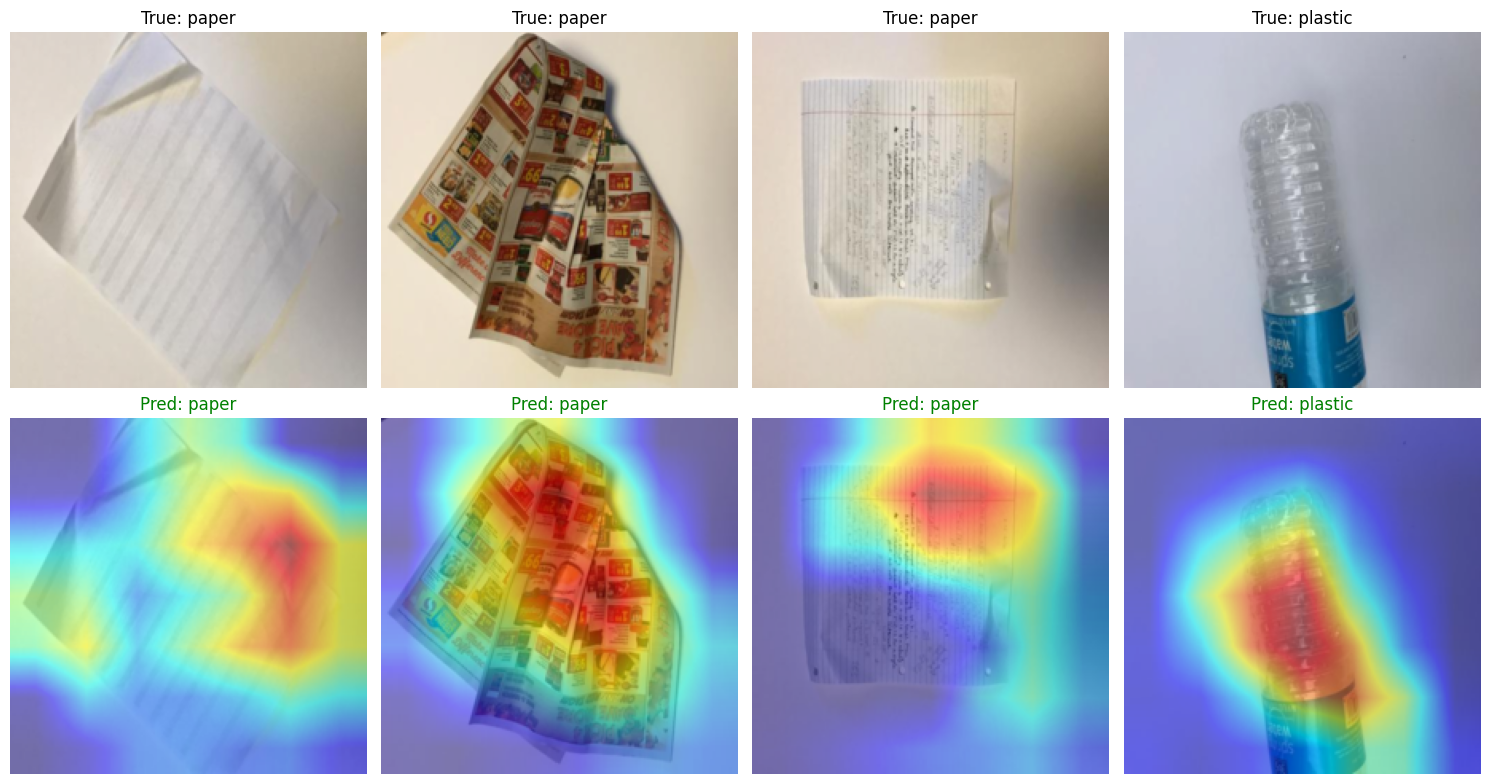

Heatmaps displayed successfully!


In [9]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# unfreeze the model parameters so Grad-CAM can backpropagate gradients
for param in model.parameters():
    param.requires_grad = True

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

print("Grad-CAM initialized. Picking 4 random test images...")

model.eval()

# --- THE FIX FOR RANDOMIZATION ---
# instead of taking the first batch, we pick 4 completely random indices from the test subset
random_indices = random.sample(range(len(test_data)), 4)

# manual batch creation from the random indices
random_images = []
random_labels = []
for idx in random_indices:
    img_tensor, label_idx = test_data[idx]
    random_images.append(img_tensor)
    random_labels.append(label_idx)

# stacking them into tensors and moving to GPU/CPU device
inputs = torch.stack(random_images).to(device)
labels = torch.tensor(random_labels).to(device)
# ---------------------------------

outputs = model(inputs)
_, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for i in range(4):
    input_tensor = inputs[i].unsqueeze(0)
    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]

    targets = [ClassifierOutputTarget(preds[i].item())]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    original_img = denormalize(inputs[i].cpu())
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)

    # Top Row: Original
    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f"True: {true_label}", fontsize=12)
    axes[0, i].axis('off')

    # Bottom Row: Heatmap
    axes[1, i].imshow(visualization)
    color = 'green' if true_label == pred_label else 'red'
    axes[1, i].set_title(f"Pred: {pred_label}", color=color, fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print("Heatmaps displayed successfully!")